In [1]:
from pathlib import Path
import json
import zipfile
import pandas as pd

In [2]:
headers_json_path = Path('../headers/headers.json')
headers_zip_path = Path('../headers/headers.zip')
if headers_json_path.exists():
    with headers_json_path.open() as handle:
        headers = json.load(handle)
elif headers_zip_path.exists():
    with zipfile.ZipFile(headers_zip_path) as archive:
        with archive.open('headers.json') as handle:
            headers = json.load(handle)
else:
    raise FileNotFoundError('Expected ../headers/headers.json or ../headers/headers.zip')
df = pd.DataFrame(headers)
df

,hash,bits,time
0,000000000019d6689c085ae165831e934ff763ae46a2a6...,1d00ffff,1231006505
1,00000000839a8e6886ab5951d76f411475428afc90947e...,1d00ffff,1231469665
2,000000006a625f06636b8bb6ac7b960a8d03705d1ace08...,1d00ffff,1231469744
3,0000000082b5015589a3fdf2d4baff403e6f0be035a5d9...,1d00ffff,1231470173
4,000000004ebadb55ee9096c9a2f8880e09da59c0d68b1c...,1d00ffff,1231470988
...,...,...,...
865038,00000000000000000002af876a1d8ce11e1c07018b016a...,17030ecd,1728572242
865039,00000000000000000000445bb08413ba56b56068395864...,17030ecd,1728572873
865040,000000000000000000019ca8e0127b00104b98ef7297e4...,17030ecd,1728573656
865041,0000000000000000000116551169c5d38e6b66b8fe27ab...,17030ecd,1728574093


In [ ]:
def bits_to_target(bits):
    """Decode the compact 'bits' field from a Bitcoin block header into a 256-bit target.

    The Bitcoin protocol encodes the proof-of-work target in a 4-byte compact
    representation called 'bits'.  The encoding follows the same convention as
    OpenSSL's MPI format, truncated to three significant bytes:

        bits   = (exponent << 24) | mantissa
        target = mantissa << (8 * (exponent - 3))

    where ``exponent`` is the most-significant byte and ``mantissa`` is the
    remaining three bytes.

    Parameters
    ----------
    bits : int or str
        The compact target value.  Accepted as a plain integer or as a
        hexadecimal string (with or without a leading '0x' prefix).

    Returns
    -------
    int
        The full 256-bit target as a Python integer.

    Example
    -------
    >>> hex(bits_to_target('1d00ffff'))   # genesis block target
    '0xffff0000000000000000000000000000000000000000000000000000'
    """
    if isinstance(bits, str):
        bits = int(bits, 16)
    bits_n = (bits >> 24) & 0xff
    bits_base = bits & 0xffffff
    target = bits_base << (8 * (bits_n - 3))
    return target

GENESIS_TARGET = bits_to_target('1d00ffff')

df = df.copy()
df['target'] = df['bits'].apply(bits_to_target)
df['difficulty'] = GENESIS_TARGET / df['target']
df

,hash,bits,time,target,difficulty
0,000000000019d6689c085ae165831e934ff763ae46a2a6...,1d00ffff,1231006505,2695953529101130949315647634472399133601089873...,1.0
1,00000000839a8e6886ab5951d76f411475428afc90947e...,1d00ffff,1231469665,2695953529101130949315647634472399133601089873...,1.0
2,000000006a625f06636b8bb6ac7b960a8d03705d1ace08...,1d00ffff,1231469744,2695953529101130949315647634472399133601089873...,1.0
3,0000000082b5015589a3fdf2d4baff403e6f0be035a5d9...,1d00ffff,1231470173,2695953529101130949315647634472399133601089873...,1.0
4,000000004ebadb55ee9096c9a2f8880e09da59c0d68b1c...,1d00ffff,1231470988,2695953529101130949315647634472399133601089873...,1.0
...,...,...,...,...,...
865038,00000000000000000002af876a1d8ce11e1c07018b016a...,17030ecd,1728572242,2928805436162009520992638294218449682899899138...,92049594548485.46875
865039,00000000000000000000445bb08413ba56b56068395864...,17030ecd,1728572873,2928805436162009520992638294218449682899899138...,92049594548485.46875
865040,000000000000000000019ca8e0127b00104b98ef7297e4...,17030ecd,1728573656,2928805436162009520992638294218449682899899138...,92049594548485.46875
865041,0000000000000000000116551169c5d38e6b66b8fe27ab...,17030ecd,1728574093,2928805436162009520992638294218449682899899138...,92049594548485.46875


In [4]:
df = df.copy()
if not pd.api.types.is_numeric_dtype(df['time']):
    raise TypeError('Column time must be numeric (Unix seconds).')
df['datetime'] = pd.to_datetime(df['time'], unit='s', utc=True)
df

,hash,bits,time,target,difficulty,datetime
0,000000000019d6689c085ae165831e934ff763ae46a2a6...,1d00ffff,1231006505,2695953529101130949315647634472399133601089873...,1.0,2009-01-03 18:15:05+00:00
1,00000000839a8e6886ab5951d76f411475428afc90947e...,1d00ffff,1231469665,2695953529101130949315647634472399133601089873...,1.0,2009-01-09 02:54:25+00:00
2,000000006a625f06636b8bb6ac7b960a8d03705d1ace08...,1d00ffff,1231469744,2695953529101130949315647634472399133601089873...,1.0,2009-01-09 02:55:44+00:00
3,0000000082b5015589a3fdf2d4baff403e6f0be035a5d9...,1d00ffff,1231470173,2695953529101130949315647634472399133601089873...,1.0,2009-01-09 03:02:53+00:00
4,000000004ebadb55ee9096c9a2f8880e09da59c0d68b1c...,1d00ffff,1231470988,2695953529101130949315647634472399133601089873...,1.0,2009-01-09 03:16:28+00:00
...,...,...,...,...,...,...
865038,00000000000000000002af876a1d8ce11e1c07018b016a...,17030ecd,1728572242,2928805436162009520992638294218449682899899138...,92049594548485.46875,2024-10-10 14:57:22+00:00
865039,00000000000000000000445bb08413ba56b56068395864...,17030ecd,1728572873,2928805436162009520992638294218449682899899138...,92049594548485.46875,2024-10-10 15:07:53+00:00
865040,000000000000000000019ca8e0127b00104b98ef7297e4...,17030ecd,1728573656,2928805436162009520992638294218449682899899138...,92049594548485.46875,2024-10-10 15:20:56+00:00
865041,0000000000000000000116551169c5d38e6b66b8fe27ab...,17030ecd,1728574093,2928805436162009520992638294218449682899899138...,92049594548485.46875,2024-10-10 15:28:13+00:00


In [5]:
df.dtypes

hash                       object
bits                       object
time                        int64
target                     object
difficulty                 object
datetime      datetime64[ns, UTC]
dtype: object

In [6]:
df = df.copy()
df['delta_t'] = df['time'].diff()
df

,hash,bits,time,target,difficulty,datetime,delta_t
0,000000000019d6689c085ae165831e934ff763ae46a2a6...,1d00ffff,1231006505,2695953529101130949315647634472399133601089873...,1.0,2009-01-03 18:15:05+00:00,NaN
1,00000000839a8e6886ab5951d76f411475428afc90947e...,1d00ffff,1231469665,2695953529101130949315647634472399133601089873...,1.0,2009-01-09 02:54:25+00:00,463160.0
2,000000006a625f06636b8bb6ac7b960a8d03705d1ace08...,1d00ffff,1231469744,2695953529101130949315647634472399133601089873...,1.0,2009-01-09 02:55:44+00:00,79.0
3,0000000082b5015589a3fdf2d4baff403e6f0be035a5d9...,1d00ffff,1231470173,2695953529101130949315647634472399133601089873...,1.0,2009-01-09 03:02:53+00:00,429.0
4,000000004ebadb55ee9096c9a2f8880e09da59c0d68b1c...,1d00ffff,1231470988,2695953529101130949315647634472399133601089873...,1.0,2009-01-09 03:16:28+00:00,815.0
...,...,...,...,...,...,...,...
865038,00000000000000000002af876a1d8ce11e1c07018b016a...,17030ecd,1728572242,2928805436162009520992638294218449682899899138...,92049594548485.46875,2024-10-10 14:57:22+00:00,64.0
865039,00000000000000000000445bb08413ba56b56068395864...,17030ecd,1728572873,2928805436162009520992638294218449682899899138...,92049594548485.46875,2024-10-10 15:07:53+00:00,631.0
865040,000000000000000000019ca8e0127b00104b98ef7297e4...,17030ecd,1728573656,2928805436162009520992638294218449682899899138...,92049594548485.46875,2024-10-10 15:20:56+00:00,783.0
865041,0000000000000000000116551169c5d38e6b66b8fe27ab...,17030ecd,1728574093,2928805436162009520992638294218449682899899138...,92049594548485.46875,2024-10-10 15:28:13+00:00,437.0


In [7]:
invalid_delta_t = int((df['delta_t'] <= 0).sum())
print(f'Nombre de delta_t <= 0: {invalid_delta_t}')

df_valid = df[df['delta_t'] > 0].copy()
print(f'Lignes conservees apres filtre: {len(df_valid)} sur {len(df)}')

df_valid

Nombre de delta_t <= 0: 15111
Lignes conservees apres filtre: 849931 sur 865043


,hash,bits,time,target,difficulty,datetime,delta_t
1,00000000839a8e6886ab5951d76f411475428afc90947e...,1d00ffff,1231469665,2695953529101130949315647634472399133601089873...,1.0,2009-01-09 02:54:25+00:00,463160.0
2,000000006a625f06636b8bb6ac7b960a8d03705d1ace08...,1d00ffff,1231469744,2695953529101130949315647634472399133601089873...,1.0,2009-01-09 02:55:44+00:00,79.0
3,0000000082b5015589a3fdf2d4baff403e6f0be035a5d9...,1d00ffff,1231470173,2695953529101130949315647634472399133601089873...,1.0,2009-01-09 03:02:53+00:00,429.0
4,000000004ebadb55ee9096c9a2f8880e09da59c0d68b1c...,1d00ffff,1231470988,2695953529101130949315647634472399133601089873...,1.0,2009-01-09 03:16:28+00:00,815.0
5,000000009b7262315dbf071787ad3656097b892abffd1f...,1d00ffff,1231471428,2695953529101130949315647634472399133601089873...,1.0,2009-01-09 03:23:48+00:00,440.0
...,...,...,...,...,...,...,...
865038,00000000000000000002af876a1d8ce11e1c07018b016a...,17030ecd,1728572242,2928805436162009520992638294218449682899899138...,92049594548485.46875,2024-10-10 14:57:22+00:00,64.0
865039,00000000000000000000445bb08413ba56b56068395864...,17030ecd,1728572873,2928805436162009520992638294218449682899899138...,92049594548485.46875,2024-10-10 15:07:53+00:00,631.0
865040,000000000000000000019ca8e0127b00104b98ef7297e4...,17030ecd,1728573656,2928805436162009520992638294218449682899899138...,92049594548485.46875,2024-10-10 15:20:56+00:00,783.0
865041,0000000000000000000116551169c5d38e6b66b8fe27ab...,17030ecd,1728574093,2928805436162009520992638294218449682899899138...,92049594548485.46875,2024-10-10 15:28:13+00:00,437.0


### Pourquoi cette formule de hashrate?

On utilise deux versions du même signal:
- `hashrate_relative = difficulty / delta_t` (proxy relatif, sans unité physique)
- `hashrate_hs_exact = difficulty * C_exact / delta_t` (estimation absolue en hashes/s)

Dérivation rapide:
- Probabilité de succès par hash: `p = target / 2^256`
- Nombre moyen de hashes pour trouver un bloc: `E[N] = 1/p = 2^256/target`
- Définition Bitcoin: `difficulty = GENESIS_TARGET / target`
- Donc `E[N] = difficulty * (2^256/GENESIS_TARGET)`

La constante exacte est:
`C_exact = 2^256 / GENESIS_TARGET`

Donc la version absolue rigoureuse (hashes/s) est:
`hashrate_hs_exact = difficulty * C_exact / delta_t`

In [8]:
C_EXACT = (2**256) / GENESIS_TARGET
df_valid['hashrate_relative'] = df_valid['difficulty'] / df_valid['delta_t']
df_valid['hashrate_hs_exact'] = df_valid['difficulty'] * C_EXACT / df_valid['delta_t']
df_valid[['hash','time','delta_t','difficulty','hashrate_relative','hashrate_hs_exact']].head()

,hash,time,delta_t,difficulty,hashrate_relative,hashrate_hs_exact
1,00000000839a8e6886ab5951d76f411475428afc90947e...,1231469665,463160.0,1.0,0.000002,9273.324193
2,000000006a625f06636b8bb6ac7b960a8d03705d1ace08...,1231469744,79.0,1.0,0.012658,54367504.21519
3,0000000082b5015589a3fdf2d4baff403e6f0be035a5d9...,1231470173,429.0,1.0,0.002331,10011731.545455
4,000000004ebadb55ee9096c9a2f8880e09da59c0d68b1c...,1231470988,815.0,1.0,0.001227,5269978.936196
5,000000009b7262315dbf071787ad3656097b892abffd1f...,1231471428,440.0,1.0,0.002273,9761438.256818


In [9]:
ROUND_SECONDS = 18  # Round duration in seconds (change as needed)

# Use block 0 (genesis) as the start of round 0.
genesis_time = int(df['time'].iloc[0])

df_rounds = df.copy()

# Assign each block to a round index: floor((time - genesis_time) / ROUND_SECONDS).
df_rounds['round_idx'] = ((df_rounds['time'] - genesis_time) // ROUND_SECONDS).astype(int)

# Deterministic model boundaries for each block's round.
df_rounds['round_start_time'] = genesis_time + df_rounds['round_idx'] * ROUND_SECONDS
df_rounds['round_end_time'] = df_rounds['round_start_time'] + ROUND_SECONDS

print(f'Round duration: {ROUND_SECONDS}s')
print(f'Genesis time (start of round 0): {genesis_time}')
print(f'Number of blocks: {len(df_rounds)}')
print(f'Number of rounds touched by blocks: {df_rounds["round_idx"].nunique()}')

df_rounds

Round duration: 18s
Genesis time (start of round 0): 1231006505
Number of blocks: 865043
Number of rounds touched by blocks: 855836


,hash,bits,time,target,difficulty,datetime,delta_t,round_idx,round_start_time,round_end_time
0,000000000019d6689c085ae165831e934ff763ae46a2a6...,1d00ffff,1231006505,2695953529101130949315647634472399133601089873...,1.0,2009-01-03 18:15:05+00:00,NaN,0,1231006505,1231006523
1,00000000839a8e6886ab5951d76f411475428afc90947e...,1d00ffff,1231469665,2695953529101130949315647634472399133601089873...,1.0,2009-01-09 02:54:25+00:00,463160.0,25731,1231469663,1231469681
2,000000006a625f06636b8bb6ac7b960a8d03705d1ace08...,1d00ffff,1231469744,2695953529101130949315647634472399133601089873...,1.0,2009-01-09 02:55:44+00:00,79.0,25735,1231469735,1231469753
3,0000000082b5015589a3fdf2d4baff403e6f0be035a5d9...,1d00ffff,1231470173,2695953529101130949315647634472399133601089873...,1.0,2009-01-09 03:02:53+00:00,429.0,25759,1231470167,1231470185
4,000000004ebadb55ee9096c9a2f8880e09da59c0d68b1c...,1d00ffff,1231470988,2695953529101130949315647634472399133601089873...,1.0,2009-01-09 03:16:28+00:00,815.0,25804,1231470977,1231470995
...,...,...,...,...,...,...,...,...,...,...
865038,00000000000000000002af876a1d8ce11e1c07018b016a...,17030ecd,1728572242,2928805436162009520992638294218449682899899138...,92049594548485.46875,2024-10-10 14:57:22+00:00,64.0,27642540,1728572225,1728572243
865039,00000000000000000000445bb08413ba56b56068395864...,17030ecd,1728572873,2928805436162009520992638294218449682899899138...,92049594548485.46875,2024-10-10 15:07:53+00:00,631.0,27642576,1728572873,1728572891
865040,000000000000000000019ca8e0127b00104b98ef7297e4...,17030ecd,1728573656,2928805436162009520992638294218449682899899138...,92049594548485.46875,2024-10-10 15:20:56+00:00,783.0,27642619,1728573647,1728573665
865041,0000000000000000000116551169c5d38e6b66b8fe27ab...,17030ecd,1728574093,2928805436162009520992638294218449682899899138...,92049594548485.46875,2024-10-10 15:28:13+00:00,437.0,27642643,1728574079,1728574097


In [10]:
# Step 1: compare sparsity for candidate round durations and build observed-round table.
ROUND_SECONDS_CANDIDATES = [18, 60, 300, 600, 1800]
diagnostics = []
for cand in ROUND_SECONDS_CANDIDATES:
    tmp_idx = ((df_valid['time'] - genesis_time) // cand).astype(int)
    observed = int(tmp_idx.nunique())  # rounds with at least one observed block-derived hashrate
    full = int(tmp_idx.max() - tmp_idx.min() + 1)  # all consecutive round indices in [min_round, max_round]
    missing = full - observed  # rounds in that range with no observed block-derived hashrate
    diagnostics.append({
        'round_seconds': cand,
        'observed_rounds': observed,
        'full_rounds': full,
        'missing_rounds': missing,
        'missing_ratio': missing / full if full > 0 else 0.0,  # missing_rounds / full_rounds
    })
round_duration_diagnostics = pd.DataFrame(diagnostics)
print('Round-duration sparsity diagnostics:')
print(' - observed_rounds: rounds that contain at least one block-derived hashrate value')
print(' - full_rounds: total consecutive rounds between first and last observed round')
print(' - missing_rounds: full_rounds - observed_rounds (empty rounds)')
print(' - missing_ratio: missing_rounds / full_rounds')
print(round_duration_diagnostics)

# Choose a larger round duration to reduce empty-round sparsity.
ROUND_SECONDS = 600

# Observed rounds only (no fill yet).
df_rounds_valid = df_valid.copy()
df_rounds_valid['round_idx'] = ((df_rounds_valid['time'] - genesis_time) // ROUND_SECONDS).astype(int)
observed_round_hashrate = (
    df_rounds_valid.groupby('round_idx', as_index=False)
    .agg(hashrate_hs_exact=('hashrate_hs_exact', 'mean'))
    .sort_values('round_idx')
    .reset_index(drop=True)
)

print(f'Chosen round duration: {ROUND_SECONDS}s')
print(f'Observed rounds with estimates: {len(observed_round_hashrate)}')

observed_round_hashrate

Round-duration sparsity diagnostics:
 - observed_rounds: rounds that contain at least one block-derived hashrate value
 - full_rounds: total consecutive rounds between first and last observed round
 - missing_rounds: full_rounds - observed_rounds (empty rounds)
 - missing_ratio: missing_rounds / full_rounds
   round_seconds  observed_rounds  full_rounds  missing_rounds  missing_ratio
0             18           842903     27616921        26774018       0.969479
1             60           816014      8285077         7469063       0.901508
2            300           670990      1657017          986027       0.595061
3            600           534928       828509          293581       0.354349
4           1800           262664       276170           13506       0.048905
Chosen round duration: 600s
Observed rounds with estimates: 534928


,round_idx,hashrate_hs_exact
0,771,9273.324193
1,772,32189617.880322
2,774,7515708.596507
3,775,11897597.875346
4,776,7405229.022414
...,...,...
534923,829274,589204218852584652800.0
534924,829276,3346784285304850219008.0
534925,829277,626554724009642295296.0
534926,829278,504924688186569981952.0


In [11]:
# Step 2: enforce consecutive round indexing and fill missing rounds.
full_round_index = pd.RangeIndex(
    int(observed_round_hashrate['round_idx'].min()),
    int(observed_round_hashrate['round_idx'].max()) + 1,
    name='round_idx',
)
round_hashrate = observed_round_hashrate.set_index('round_idx').reindex(full_round_index)
missing_before_fill = int(round_hashrate['hashrate_hs_exact'].isna().sum())

# Ensure numeric dtype before interpolation on the reindexed series.
round_hashrate['hashrate_hs_exact'] = pd.to_numeric(round_hashrate['hashrate_hs_exact'], errors='coerce')

# Fill gaps with linear interpolation (then edge fill).
round_hashrate['hashrate_hs_exact'] = round_hashrate['hashrate_hs_exact'].interpolate(method='linear')
round_hashrate['hashrate_hs_exact'] = round_hashrate['hashrate_hs_exact'].ffill().bfill()
round_hashrate = round_hashrate.reset_index()

print(f'Total consecutive rounds in range: {len(round_hashrate)}')
print(f'Rounds missing before fill: {missing_before_fill}')
print(f'Missing ratio before fill: {missing_before_fill / len(round_hashrate):.4%}')

round_hashrate.head(20)

Total consecutive rounds in range: 828509
Rounds missing before fill: 293581
Missing ratio before fill: 35.4349%


,round_idx,hashrate_hs_exact
0,771,9.273324e+03
1,772,3.218962e+07
2,773,1.985266e+07
3,774,7.515709e+06
4,775,1.189760e+07
5,776,7.405229e+06
6,777,9.748583e+06
7,778,9.101532e+06
8,779,8.454481e+06
9,780,2.033633e+07


In [ ]:
# Step 3: compute gamma(s) on the final consecutive-round hashrate series.
S_INPUT = 200

def gamma_for_s_hashrate(hashrate_series: pd.Series, s: int) -> tuple[float, int, int]:
    """Compute gamma(s) — the worst-case hashrate ratio over all contiguous windows of at most s rounds.

    For a sequence of per-round hashrate estimates H = [h_0, h_1, ..., h_{n-1}],
    gamma(s) is defined as:

        gamma(s) = max_{1 <= w <= s} max_{end} ( max(H[end-w+1 .. end]) / min(H[end-w+1 .. end]) )

    Intuitively it answers: "over the worst contiguous window of up to s consecutive
    rounds, by what factor can the observed hashrate vary?"  A value of 1.0 means the
    hashrate is perfectly constant; larger values indicate higher variability.

    The series is first sanitised: NaN entries are dropped, values are cast to float,
    and non-positive values are removed.  The window size s is capped at the number of
    remaining data points.

    Parameters
    ----------
    hashrate_series : pd.Series
        Per-round hashrate estimates (consecutive round indices, may contain NaN).
        Typically the ``hashrate_hs_exact`` column of the reindexed round table.
    s : int
        Maximum window length in rounds to consider.  Must be >= 1.

    Returns
    -------
    gamma_s : float
        The worst-case max/min ratio across all windows of size 1 to s_eff.
        Returns 1.0 if every window has identical hashrate or s_eff == 0.
    worst_w : int
        The window size (number of rounds) that produced gamma_s.
    worst_end : int
        The (0-based) position in the sanitised series at which the worst
        window ends (inclusive).

    Raises
    ------
    ValueError
        If the series contains no finite positive values after sanitisation.
    """
    h = hashrate_series.dropna().astype(float).reset_index(drop=True)
    h = h[h > 0].reset_index(drop=True)
    if h.empty:
        raise ValueError('Hashrate series must contain at least one positive value.')

    s_eff = min(s, len(h))  # Effective s cannot exceed available number of rounds.
    gamma_s = 1.0            # Neutral baseline ratio max/min for a constant window.
    worst_w = 1              # Window-size tracker for the current worst-case ratio.
    worst_end = 0            # End-index tracker for the current worst-case ratio.

    for w in range(1, s_eff + 1):
        roll_max = h.rolling(window=w, min_periods=w).max()
        roll_min = h.rolling(window=w, min_periods=w).min()
        ratio = roll_max / roll_min
        local = ratio.max()
        if pd.notna(local) and float(local) > gamma_s:
            gamma_s = float(local)
            worst_w = w
            worst_end = int(ratio.idxmax())

    return gamma_s, worst_w, worst_end

gamma_abs, worst_w_abs, worst_end_abs = gamma_for_s_hashrate(round_hashrate['hashrate_hs_exact'], S_INPUT)
s_effective = min(S_INPUT, len(round_hashrate))

print(f'Requested s: {S_INPUT}')
print(f'Effective s (capped by available rounds): {s_effective}')
print(f'gamma_abs_exact(s): {gamma_abs:.6f}')
print(f'Worst absolute window: size={worst_w_abs}, end={worst_end_abs}')

Requested s: 200
Effective s (capped by available rounds): 200
gamma_abs_exact(s): 19300.990378
Worst absolute window: size=157, end=156


Gamma sweep done in 837.64s (parallel=True, workers=23)
Computed combinations: 42


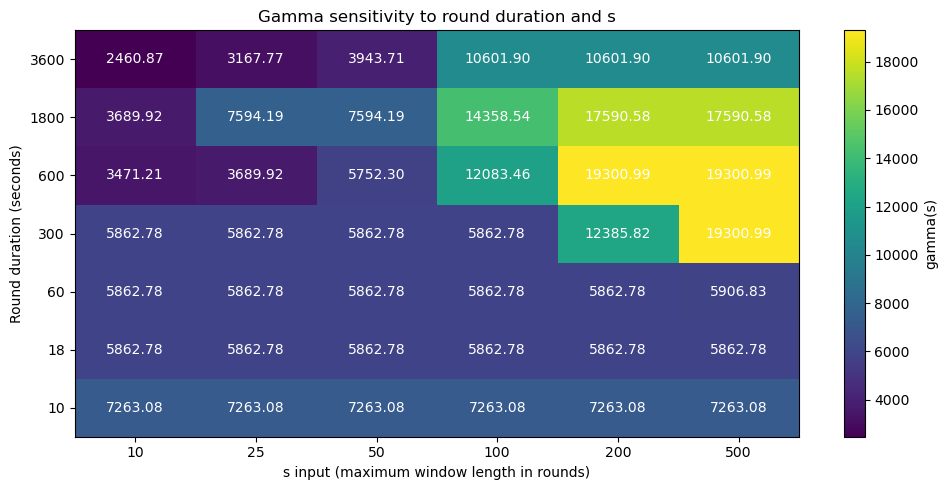

,round_seconds,s_input,s_effective,available_rounds,gamma
0,10,10,10,49710456,7263.083333
1,10,25,25,49710456,7263.083333
2,10,50,50,49710456,7263.083333
3,10,100,100,49710456,7263.083333
4,10,200,200,49710456,7263.083333
5,10,500,500,49710456,7263.083333
6,18,10,10,27616921,5862.784810
7,18,25,25,27616921,5862.784810
8,18,50,50,27616921,5862.784810
9,18,100,100,27616921,5862.784810


In [ ]:
import os
import time
import matplotlib.pyplot as plt
from concurrent.futures import ThreadPoolExecutor

# Sweep both round duration and s to visualize how gamma behaves.
ROUND_SECONDS_GRID = [10, 18, 60, 300, 600, 1800, 3600]
S_INPUT_GRID = [10, 25, 50, 100, 200, 500]

# Toggle parallel execution for the parameter sweep.
USE_PARALLEL = True
MAX_WORKERS = max(1, (os.cpu_count() or 1) - 1)

def build_round_hashrate_for_seconds(round_seconds: int) -> pd.DataFrame:
    """Build a consecutive-round exact hashrate table for a chosen round duration.

    Assigns each block in ``df_valid`` to a round index using floor division:

        round_idx = floor((block_time - genesis_time) / round_seconds)

    Blocks in the same round are averaged.  The resulting sparse series is then
    expanded to cover every consecutive round between the first and last observed
    round, and empty rounds are filled via linear interpolation followed by
    forward/backward fill for any remaining edge gaps.

    This function mirrors the logic in cell 12 but accepts an arbitrary
    ``round_seconds`` value so it can be called inside the sensitivity sweep
    without mutating the global ``ROUND_SECONDS`` variable.

    Parameters
    ----------
    round_seconds : int
        Duration of each round in seconds.  Must be > 0.

    Returns
    -------
    pd.DataFrame
        A DataFrame with columns ``round_idx`` (int) and ``hashrate_hs_exact``
        (float), indexed 0 … N-1, where N = max_round - min_round + 1.  No NaN
        values remain after the fill step.
    """
    tmp = df_valid.copy()
    tmp['round_idx'] = ((tmp['time'] - genesis_time) // round_seconds).astype(int)

    observed = (
        tmp.groupby('round_idx', as_index=False)
        .agg(hashrate_hs_exact=('hashrate_hs_exact', 'mean'))
        .sort_values('round_idx')
        .reset_index(drop=True)
    )

    full_index = pd.RangeIndex(
        int(observed['round_idx'].min()),
        int(observed['round_idx'].max()) + 1,
        name='round_idx',
    )
    completed = observed.set_index('round_idx').reindex(full_index)
    completed['hashrate_hs_exact'] = pd.to_numeric(
        completed['hashrate_hs_exact'], errors='coerce'
    )
    completed['hashrate_hs_exact'] = completed['hashrate_hs_exact'].interpolate(method='linear')
    completed['hashrate_hs_exact'] = completed['hashrate_hs_exact'].ffill().bfill()
    return completed.reset_index()

def compute_one_combination(task: tuple[int, int, dict[int, pd.DataFrame]]) -> dict[str, float | int]:
    """Compute the gamma row for one (round_seconds, s_input) parameter combination.

    Looks up the pre-built consecutive-round hashrate series for ``round_seconds``
    from the shared ``series_map`` and delegates to ``gamma_for_s_hashrate``.
    The result is returned as a plain dict so it can be collected into a DataFrame
    after parallel mapping.

    Accepting all inputs as a single tuple allows this function to be passed
    directly to ``ThreadPoolExecutor.map`` without a lambda or ``functools.partial``.

    Parameters
    ----------
    task : tuple[int, int, dict[int, pd.DataFrame]]
        A 3-tuple of:
        - ``round_seconds`` (int): round duration used to look up the hashrate series.
        - ``s_value`` (int): maximum window length passed to ``gamma_for_s_hashrate``.
        - ``series_map`` (dict): mapping from round_seconds to the corresponding
          consecutive-round hashrate DataFrame produced by
          ``build_round_hashrate_for_seconds``.

    Returns
    -------
    dict[str, float | int]
        A row dict with keys ``round_seconds``, ``s_input``, ``s_effective``,
        ``available_rounds``, and ``gamma``.
    """
    round_seconds, s_value, series_map = task
    local_round_hashrate = series_map[round_seconds]
    available_rounds = len(local_round_hashrate)
    gamma_value, _, _ = gamma_for_s_hashrate(
        local_round_hashrate['hashrate_hs_exact'], s_value
    )
    return {
        'round_seconds': round_seconds,
        's_input': s_value,
        's_effective': min(s_value, available_rounds),
        'available_rounds': available_rounds,
        'gamma': gamma_value,
    }

# Precompute one round-hashrate series per round_seconds value.
start = time.perf_counter()
if USE_PARALLEL and len(ROUND_SECONDS_GRID) > 1:
    with ThreadPoolExecutor(max_workers=min(MAX_WORKERS, len(ROUND_SECONDS_GRID))) as executor:
        precomputed_list = list(executor.map(build_round_hashrate_for_seconds, ROUND_SECONDS_GRID))
    round_series_map = dict(zip(ROUND_SECONDS_GRID, precomputed_list))
else:
    round_series_map = {
        rs: build_round_hashrate_for_seconds(rs) for rs in ROUND_SECONDS_GRID
    }

# Build tasks for each combination (round_seconds, s_input).
combination_tasks = [
    (rs, s, round_series_map)
    for rs in ROUND_SECONDS_GRID
    for s in S_INPUT_GRID
]

# Parallelize at the combination level.
if USE_PARALLEL and len(combination_tasks) > 1:
    with ThreadPoolExecutor(max_workers=min(MAX_WORKERS, len(combination_tasks))) as executor:
        gamma_grid_rows = list(executor.map(compute_one_combination, combination_tasks))
else:
    gamma_grid_rows = [compute_one_combination(task) for task in combination_tasks]

elapsed = time.perf_counter() - start
print(f'Gamma sweep done in {elapsed:.2f}s (parallel={USE_PARALLEL}, workers={MAX_WORKERS})')
print(f'Computed combinations: {len(combination_tasks)}')

gamma_grid = pd.DataFrame(gamma_grid_rows)
gamma_heatmap = gamma_grid.pivot(index='round_seconds', columns='s_input', values='gamma')

fig, ax = plt.subplots(figsize=(10, 5))
image = ax.imshow(gamma_heatmap.values, aspect='auto', origin='lower')
ax.set_xticks(range(len(gamma_heatmap.columns)))
ax.set_xticklabels(gamma_heatmap.columns)
ax.set_yticks(range(len(gamma_heatmap.index)))
ax.set_yticklabels(gamma_heatmap.index)
ax.set_xlabel('s input (maximum window length in rounds)')
ax.set_ylabel('Round duration (seconds)')
ax.set_title('Gamma sensitivity to round duration and s')

for row_idx in range(len(gamma_heatmap.index)):
    for col_idx in range(len(gamma_heatmap.columns)):
        value = gamma_heatmap.iloc[row_idx, col_idx]
        ax.text(col_idx, row_idx, f'{value:.2f}', ha='center', va='center', color='white')

fig.colorbar(image, ax=ax, label='gamma(s)')
plt.tight_layout()
plt.savefig('gamma-sensitivity-round-duration-vs-s.pdf', format='pdf')
plt.show()

gamma_grid